In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

In [12]:
rawdata = """
Date,Store_ID,SKU_Category,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales
2023-10-01,ST-001,Produce,0.80,2.50,150,110,40,0,0,0
2023-10-01,ST-001,Dairy,1.50,3.99,80,80,0,1,1,15
2023-10-01,ST-001,Bakery,1.20,4.50,60,45,15,0,0,0
2023-10-01,ST-001,Pantry,2.00,5.50,100,95,5,0,0,0
2023-10-01,ST-002,Produce,0.80,2.50,120,120,0,1,0,8
2023-10-01,ST-002,Dairy,1.50,3.99,90,75,15,0,0,0
2023-10-01,ST-002,Bakery,1.20,4.50,50,50,0,1,1,20
2023-10-01,ST-003,Produce,0.80,2.50,200,160,40,0,0,0
2023-10-02,ST-001,Produce,0.80,2.50,130,130,0,1,1,25
2023-10-02,ST-001,Dairy,1.50,3.99,100,82,18,0,0,0
"""
data = pd.read_csv(StringIO(rawdata))

In [13]:
data

,Date,Store_ID,SKU_Category,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales
0,2023-10-01,ST-001,Produce,0.8,2.50,150,110,40,0,0,0
1,2023-10-01,ST-001,Dairy,1.5,3.99,80,80,0,1,1,15
2,2023-10-01,ST-001,Bakery,1.2,4.50,60,45,15,0,0,0
3,2023-10-01,ST-001,Pantry,2.0,5.50,100,95,5,0,0,0
4,2023-10-01,ST-002,Produce,0.8,2.50,120,120,0,1,0,8
5,2023-10-01,ST-002,Dairy,1.5,3.99,90,75,15,0,0,0
6,2023-10-01,ST-002,Bakery,1.2,4.50,50,50,0,1,1,20
7,2023-10-01,ST-003,Produce,0.8,2.50,200,160,40,0,0,0
8,2023-10-02,ST-001,Produce,0.8,2.50,130,130,0,1,1,25
9,2023-10-02,ST-001,Dairy,1.5,3.99,100,82,18,0,0,0


In [14]:
data.head(7)

,Date,Store_ID,SKU_Category,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales
0,2023-10-01,ST-001,Produce,0.8,2.50,150,110,40,0,0,0
1,2023-10-01,ST-001,Dairy,1.5,3.99,80,80,0,1,1,15
2,2023-10-01,ST-001,Bakery,1.2,4.50,60,45,15,0,0,0
3,2023-10-01,ST-001,Pantry,2.0,5.50,100,95,5,0,0,0
4,2023-10-01,ST-002,Produce,0.8,2.50,120,120,0,1,0,8
5,2023-10-01,ST-002,Dairy,1.5,3.99,90,75,15,0,0,0
6,2023-10-01,ST-002,Bakery,1.2,4.50,50,50,0,1,1,20


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                10 non-null     object 
 1   Store_ID            10 non-null     object 
 2   SKU_Category        10 non-null     object 
 3   Unit_Cost           10 non-null     float64
 4   Retail_Price        10 non-null     float64
 5   Units_Ordered       10 non-null     int64  
 6   Units_Sold          10 non-null     int64  
 7   Units_Spoiled       10 non-null     int64  
 8   Stockout_Flag       10 non-null     int64  
 9   Peak_Hour_Stockout  10 non-null     int64  
 10  Est_Lost_Sales      10 non-null     int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 1012.0+ bytes


In [16]:
data.describe()

,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales
count,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,1.210000,3.64700,108.000000,94.700000,13.300000,0.400000,0.300000,6.800000
std,0.414863,1.08034,44.422217,35.929097,15.741312,0.516398,0.483046,9.727395
min,0.800000,2.50000,50.000000,45.000000,0.000000,0.000000,0.000000,0.000000
25%,0.800000,2.50000,82.500000,76.250000,0.000000,0.000000,0.000000,0.000000
50%,1.200000,3.99000,100.000000,88.500000,10.000000,0.000000,0.000000,0.000000
75%,1.500000,4.37250,127.500000,117.500000,17.250000,1.000000,0.750000,13.250000
max,2.000000,5.50000,200.000000,160.000000,40.000000,1.000000,1.000000,25.000000


In [17]:
data.isna().sum()

Date                  0
Store_ID              0
SKU_Category          0
Unit_Cost             0
Retail_Price          0
Units_Ordered         0
Units_Sold            0
Units_Spoiled         0
Stockout_Flag         0
Peak_Hour_Stockout    0
Est_Lost_Sales        0
dtype: int64

In [21]:
data["Wastage_Loss"] = (data["Units_Spoiled"]*data["Unit_Cost"])

In [22]:
data

,Date,Store_ID,SKU_Category,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales,Wastage_Loss
0,2023-10-01,ST-001,Produce,0.8,2.50,150,110,40,0,0,0,32.0
1,2023-10-01,ST-001,Dairy,1.5,3.99,80,80,0,1,1,15,0.0
2,2023-10-01,ST-001,Bakery,1.2,4.50,60,45,15,0,0,0,18.0
3,2023-10-01,ST-001,Pantry,2.0,5.50,100,95,5,0,0,0,10.0
4,2023-10-01,ST-002,Produce,0.8,2.50,120,120,0,1,0,8,0.0
5,2023-10-01,ST-002,Dairy,1.5,3.99,90,75,15,0,0,0,22.5
6,2023-10-01,ST-002,Bakery,1.2,4.50,50,50,0,1,1,20,0.0
7,2023-10-01,ST-003,Produce,0.8,2.50,200,160,40,0,0,0,32.0
8,2023-10-02,ST-001,Produce,0.8,2.50,130,130,0,1,1,25,0.0
9,2023-10-02,ST-001,Dairy,1.5,3.99,100,82,18,0,0,0,27.0


In [23]:
data["Wastage_Loss"].sum()

np.float64(141.5)

In [24]:
data.groupby("SKU_Category")["Wastage_Loss"].sum()

SKU_Category
Bakery     18.0
Dairy      49.5
Pantry     10.0
Produce    64.0
Name: Wastage_Loss, dtype: float64

In [25]:
data.groupby("Store_ID")["Wastage_Loss"].sum()

Store_ID
ST-001    87.0
ST-002    22.5
ST-003    32.0
Name: Wastage_Loss, dtype: float64

In [26]:
data["Lost_Revenue"] = (data["Est_Lost_Sales"]*data["Retail_Price"])

In [27]:
data

,Date,Store_ID,SKU_Category,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales,Wastage_Loss,Lost_Revenue
0,2023-10-01,ST-001,Produce,0.8,2.50,150,110,40,0,0,0,32.0,0.00
1,2023-10-01,ST-001,Dairy,1.5,3.99,80,80,0,1,1,15,0.0,59.85
2,2023-10-01,ST-001,Bakery,1.2,4.50,60,45,15,0,0,0,18.0,0.00
3,2023-10-01,ST-001,Pantry,2.0,5.50,100,95,5,0,0,0,10.0,0.00
4,2023-10-01,ST-002,Produce,0.8,2.50,120,120,0,1,0,8,0.0,20.00
5,2023-10-01,ST-002,Dairy,1.5,3.99,90,75,15,0,0,0,22.5,0.00
6,2023-10-01,ST-002,Bakery,1.2,4.50,50,50,0,1,1,20,0.0,90.00
7,2023-10-01,ST-003,Produce,0.8,2.50,200,160,40,0,0,0,32.0,0.00
8,2023-10-02,ST-001,Produce,0.8,2.50,130,130,0,1,1,25,0.0,62.50
9,2023-10-02,ST-001,Dairy,1.5,3.99,100,82,18,0,0,0,27.0,0.00


In [28]:
data["Lost_Revenue"].sum()

np.float64(232.35)

In [30]:
data.groupby("SKU_Category")["Lost_Revenue"].sum()

SKU_Category
Bakery     90.00
Dairy      59.85
Pantry      0.00
Produce    82.50
Name: Lost_Revenue, dtype: float64

In [31]:
data[data["Peak_Hour_Stockout"] == 1]

,Date,Store_ID,SKU_Category,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales,Wastage_Loss,Lost_Revenue
1,2023-10-01,ST-001,Dairy,1.5,3.99,80,80,0,1,1,15,0.0,59.85
6,2023-10-01,ST-002,Bakery,1.2,4.50,50,50,0,1,1,20,0.0,90.00
8,2023-10-02,ST-001,Produce,0.8,2.50,130,130,0,1,1,25,0.0,62.50


<Axes: >

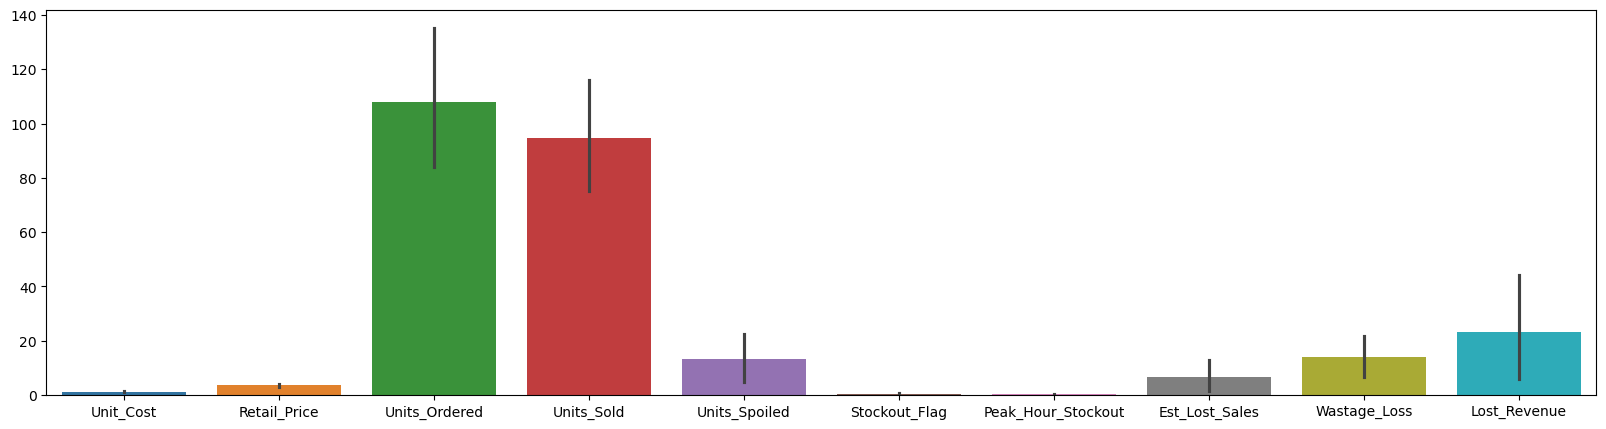

In [38]:
plt.figure(figsize=(20,5))
sns.barplot(data)

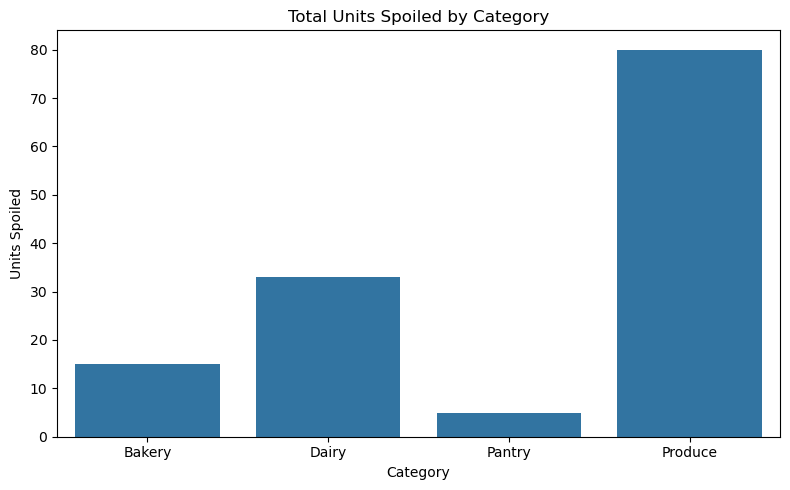

In [39]:
wastage_by_category = data.groupby("SKU_Category")["Units_Spoiled"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=wastage_by_category, x="SKU_Category", y="Units_Spoiled")

plt.title("Total Units Spoiled by Category")
plt.xlabel("Category")
plt.ylabel("Units Spoiled")

plt.tight_layout()
plt.show()

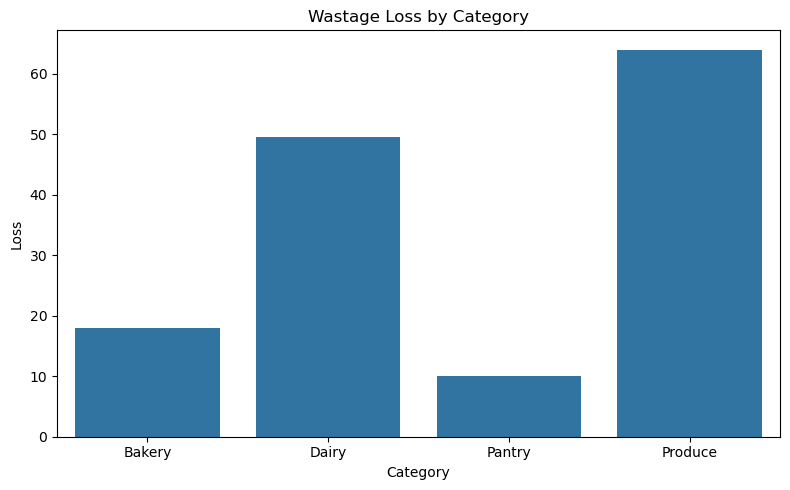

In [40]:
loss_by_category = data.groupby("SKU_Category")["Wastage_Loss"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=loss_by_category, x="SKU_Category", y="Wastage_Loss")

plt.title("Wastage Loss by Category")
plt.xlabel("Category")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

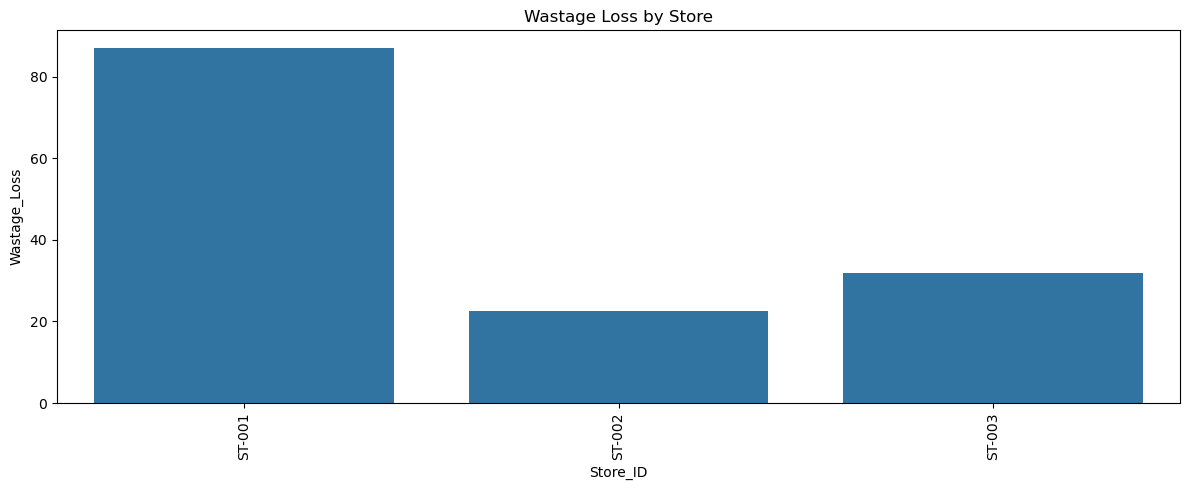

In [41]:
store_loss = data.groupby("Store_ID")["Wastage_Loss"].sum().reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=store_loss, x="Store_ID", y="Wastage_Loss")

plt.xticks(rotation=90)
plt.title("Wastage Loss by Store")

plt.tight_layout()
plt.show()

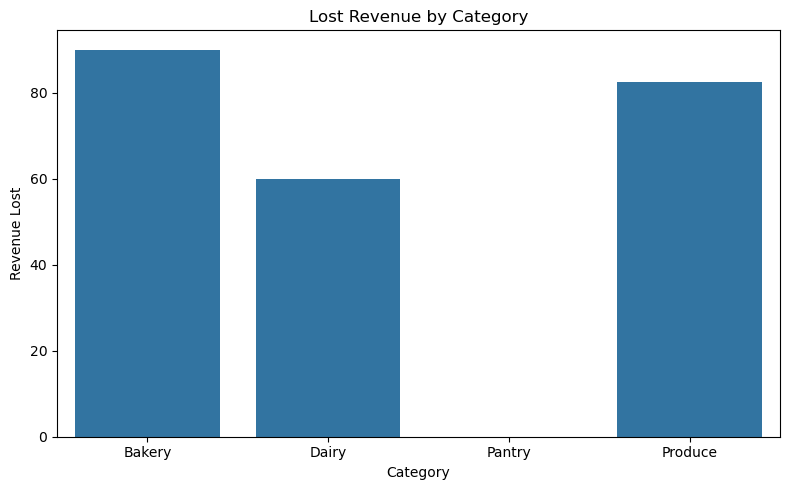

In [42]:
lost_revenue_category = data.groupby("SKU_Category")["Lost_Revenue"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=lost_revenue_category, x="SKU_Category", y="Lost_Revenue")

plt.title("Lost Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue Lost")

plt.tight_layout()
plt.show()

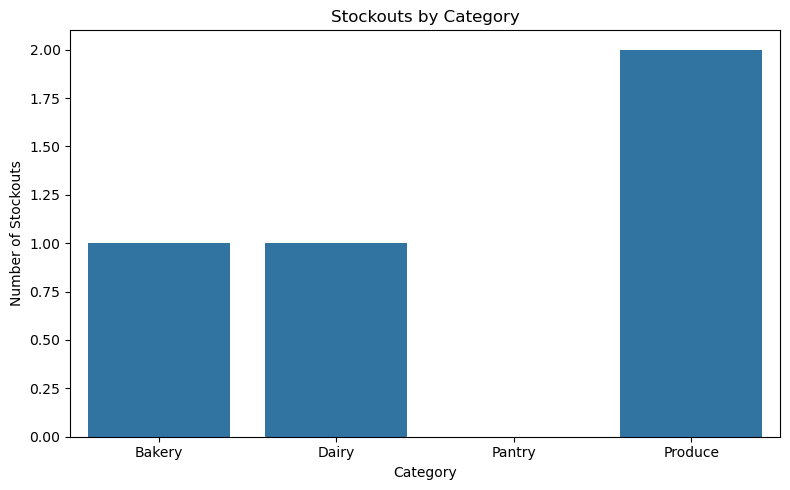

In [43]:
stockouts = data.groupby("SKU_Category")["Stockout_Flag"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=stockouts, x="SKU_Category", y="Stockout_Flag")

plt.title("Stockouts by Category")
plt.xlabel("Category")
plt.ylabel("Number of Stockouts")

plt.tight_layout()
plt.show()

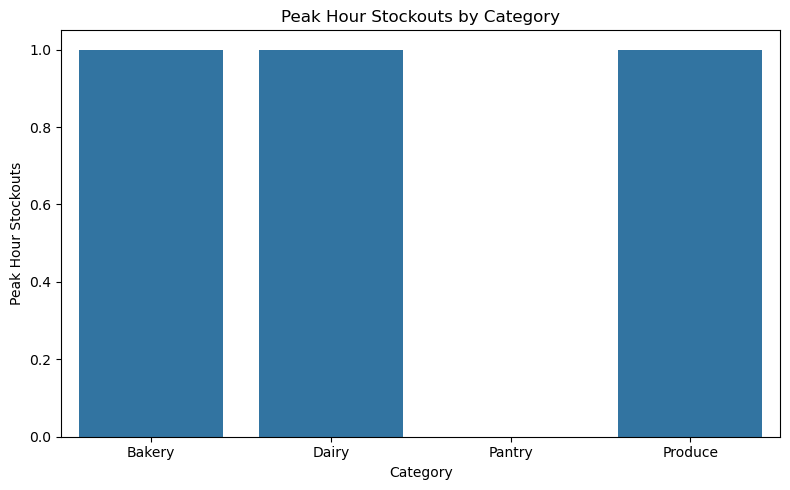

In [44]:
peak_stockouts = data.groupby("SKU_Category")["Peak_Hour_Stockout"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=peak_stockouts, x="SKU_Category", y="Peak_Hour_Stockout")

plt.title("Peak Hour Stockouts by Category")
plt.xlabel("Category")
plt.ylabel("Peak Hour Stockouts")

plt.tight_layout()
plt.show()

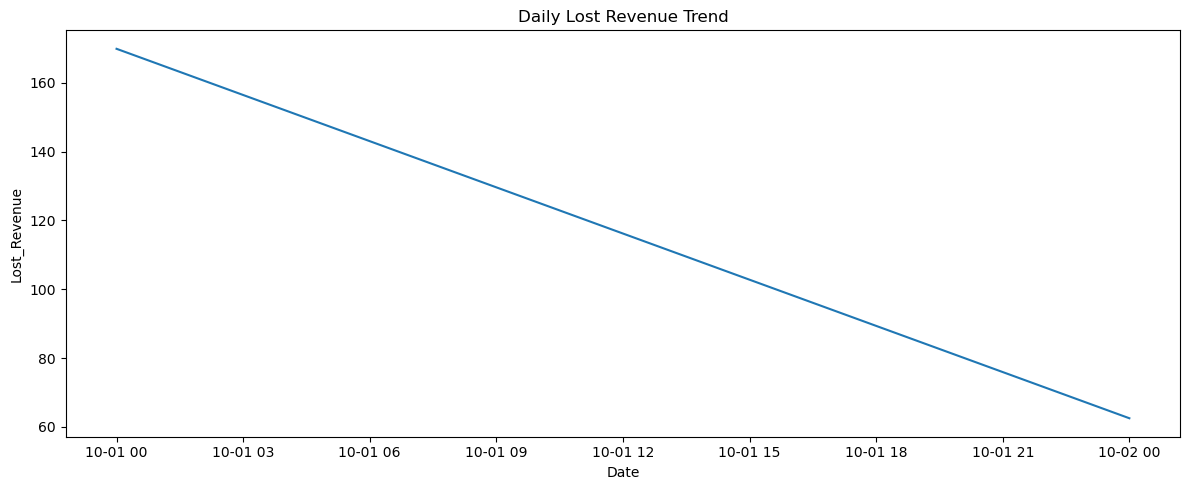

In [45]:
data["Date"] = pd.to_datetime(data["Date"])
daily_loss = data.groupby("Date")["Lost_Revenue"].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=daily_loss, x="Date", y="Lost_Revenue")
plt.title("Daily Lost Revenue Trend")

plt.tight_layout()
plt.show()

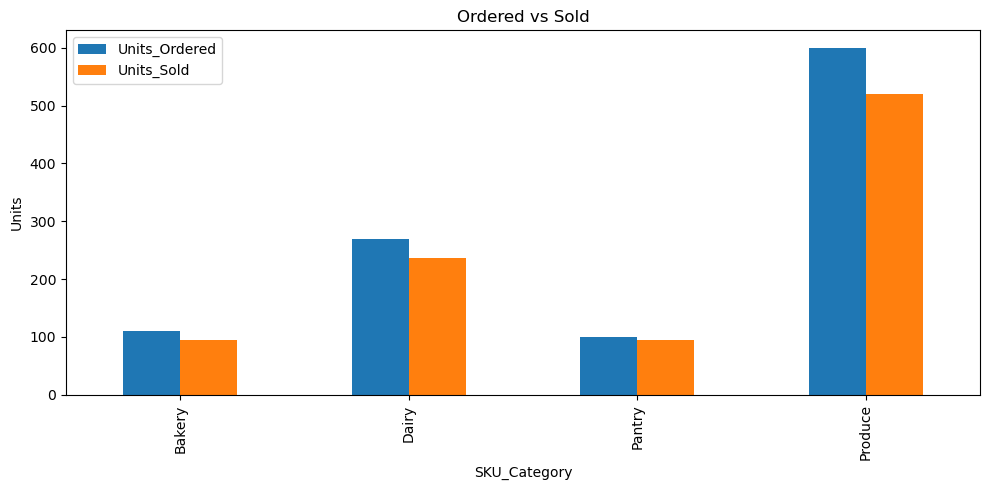

In [46]:
comparison = data.groupby("SKU_Category")[["Units_Ordered","Units_Sold"]].sum().reset_index()
comparison.plot( x="SKU_Category", kind="bar", figsize=(10,5))

plt.title("Ordered vs Sold")
plt.ylabel("Units")

plt.tight_layout()
plt.show()